# Phase 4: Enhancing Regression Model for FD001

This notebook improves the regression model for predicting `cycles_to_next_stage` in the FD001 dataset. We’ll load the data, engineer advanced features, tune models, and ensemble them for better performance.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import StandardScaler

# Set base directory
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
DATA_FILE = os.path.join(BASE_DIR, 'data', 'regression_train_FD001.csv')

# Load the regression-labeled dataset
df = pd.read_csv(DATA_FILE)
df = df.dropna(subset=['cycles_to_next_stage']).reset_index(drop=True)
print(f'✅ Loaded FD001 regression dataset: {df.shape}')
df[['unit', 'time', 'final_stage', 'cycles_to_next_stage']].head()

✅ Loaded FD001 regression dataset: (18028, 28)


,unit,time,final_stage,cycles_to_next_stage
0,1,1,4,12.0
1,1,2,4,11.0
2,1,3,4,10.0
3,1,4,4,9.0
4,1,5,4,8.0


## Step 1: Advanced Feature Engineering

We’ll add rolling statistics (min, max, std), differences, and interaction features to capture more patterns in the time-series data.

In [2]:
def add_advanced_features(df, window=5):
    df = df.sort_values(by=['unit', 'time']).copy()
    sensor_cols = [col for col in df.columns if col.startswith('sensor_')]
    
    for col in sensor_cols:
        # Rolling minimum
        df[f'{col}_rollmin_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).min()
        )
        # Rolling maximum
        df[f'{col}_rollmax_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).max()
        )
        # Rolling standard deviation
        df[f'{col}_rollstd_{window}'] = df.groupby('unit')[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).std().fillna(0)
        )
        # First-order difference
        df[f'{col}_delta'] = df.groupby('unit')[col].diff().fillna(0)
    
    # Interaction features (example: ratio between two sensors)
    if 'sensor_2' in sensor_cols and 'sensor_3' in sensor_cols:
        df['sensor_2_3_ratio'] = df['sensor_2'] / (df['sensor_3'] + 1e-6)  # Avoid division by zero
    
    return df

# Apply feature engineering
df = add_advanced_features(df)
print('✅ Advanced features added')
df.head()

✅ Advanced features added


,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_17_delta,sensor_20_rollmin_5,sensor_20_rollmax_5,sensor_20_rollstd_5,sensor_20_delta,sensor_21_rollmin_5,sensor_21_rollmax_5,sensor_21_rollstd_5,sensor_21_delta,sensor_2_3_ratio
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,1.0,0.726248,...,0.000000,0.713178,0.713178,0.000000,0.000000,0.724662,0.724662,0.000000,0.000000,0.451656
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,1.0,0.628019,...,0.000000,0.666667,0.713178,0.032889,-0.046512,0.724662,0.731014,0.004491,0.006352,0.624988
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,1.0,0.710145,...,-0.166667,0.627907,0.713178,0.042694,-0.038760,0.621375,0.731014,0.061548,-0.109638,0.929233
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,1.0,0.740741,...,0.166667,0.573643,0.713178,0.059164,-0.054264,0.621375,0.731014,0.052440,0.041011,1.340466
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,1.0,0.668277,...,0.083333,0.573643,0.713178,0.057070,0.015504,0.621375,0.731014,0.046256,0.042115,1.357054


## Step 2: Feature Selection and Train-Test Split

Select all sensor-related features (original + engineered) and perform an engine-stratified train-test split.

In [3]:
# Define features and target
feature_cols = [col for col in df.columns if col.startswith('sensor_') or 'roll' in col or 'delta' in col or 'ratio' in col]
target_col = 'cycles_to_next_stage'

X = df[feature_cols]
y = df[target_col]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Engine-stratified split
units = df['unit'].unique()
train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)
train_df = df[df['unit'].isin(train_units)].reset_index(drop=True)
test_df = df[df['unit'].isin(test_units)].reset_index(drop=True)

X_train = X.loc[train_df.index]
y_train = y.loc[train_df.index]
X_test = X.loc[test_df.index]
y_test = y.loc[test_df.index]

print(f'✅ Train shape: {X_train.shape} | Test shape: {X_test.shape}')
print(f'🔍 Train engine count: {train_df["unit"].nunique()}')
print(f'🔍 Test engine count: {test_df["unit"].nunique()}')

✅ Train shape: (14490, 76) | Test shape: (3538, 76)
🔍 Train engine count: 80
🔍 Test engine count: 20


## Step 3: Model Training and Tuning

We’ll train and tune three models: Random Forest, XGBoost, and LightGBM.

Random Forest Evaluation Metrics (FD001):
RMSE: 6.83
MAE : 5.27
R²  : 0.9456


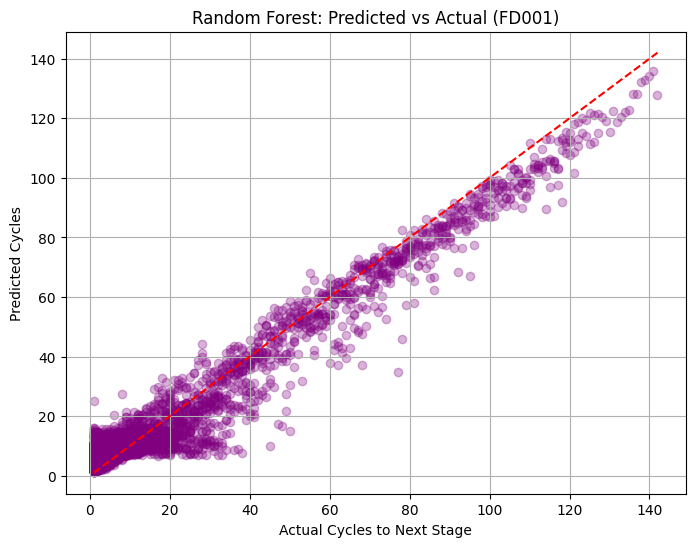

Best RF Params: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': 15}
XGBoost Evaluation Metrics (FD001):
RMSE: 4.45
MAE : 3.31
R²  : 0.9769


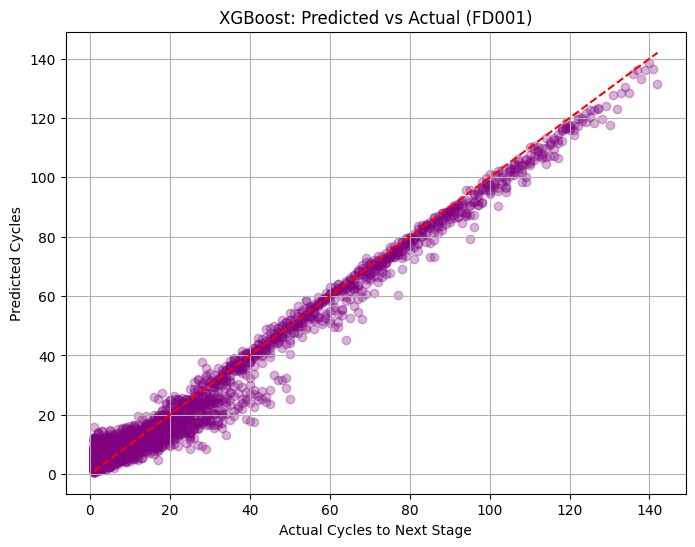

Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001353 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14493
[LightGBM] [Info] Number of data points in the train set: 11592, number of used features: 75
[LightGBM] [Info] Start training from score 16.526829
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

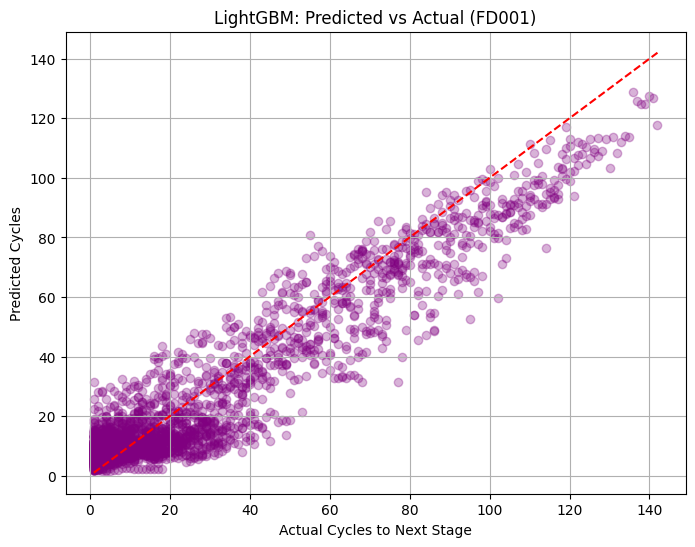

Best LGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [4]:
# Helper function to evaluate and plot
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'{name} Evaluation Metrics (FD001):')
    print(f'RMSE: {rmse:.2f}')
    print(f'MAE : {mae:.2f}')
    print(f'R²  : {r2:.4f}')
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Cycles to Next Stage')
    plt.ylabel('Predicted Cycles')
    plt.title(f'{name}: Predicted vs Actual (FD001)')
    plt.grid(True)
    plt.show()
    return model, y_pred

# Random Forest with tuning
rf_params = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 12, 15],
    'min_samples_split': [2, 5]
}
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(rf, rf_params, n_iter=10, cv=5, scoring='neg_root_mean_squared_error', random_state=42)
rf_model, rf_pred = evaluate_model(rf_search, X_train, y_train, X_test, y_test, 'Random Forest')
print(f'Best RF Params: {rf_search.best_params_}')

# XGBoost with tuning
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_reg = xgb.XGBRegressor(random_state=42, n_jobs=-1)
xgb_search = RandomizedSearchCV(xgb_reg, xgb_params, n_iter=10, cv=5, scoring='neg_root_mean_squared_error', random_state=42)
xgb_model, xgb_pred = evaluate_model(xgb_search, X_train, y_train, X_test, y_test, 'XGBoost')
print(f'Best XGB Params: {xgb_search.best_params_}')

# LightGBM with tuning
lgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
lgb_reg = lgb.LGBMRegressor(random_state=42, n_jobs=-1)
lgb_search = RandomizedSearchCV(lgb_reg, lgb_params, n_iter=10, cv=5, scoring='neg_root_mean_squared_error', random_state=42)
lgb_model, lgb_pred = evaluate_model(lgb_search, X_train, y_train, X_test, y_test, 'LightGBM')
print(f'Best LGB Params: {lgb_search.best_params_}')

## Step 4: Save the Best Model

Save the ensemble approach as a dictionary of models.

In [5]:
# Save models
model_dict = {
    'rf': rf_model.best_estimator_,
    'xgb': xgb_model.best_estimator_,
    'lgb': lgb_model.best_estimator_,
    'scaler': scaler
}
model_path = os.path.join(BASE_DIR, 'models', 'phase4', 'ensemble_fd001.pkl')
joblib.dump(model_dict, model_path)
print(f'✅ Ensemble model saved to: {model_path}')

✅ Ensemble model saved to: /Users/pranavreddy/Desktop/hybrid-predictive-maintenance/models/phase4/ensemble_fd001.pkl


## Summary

- **Feature Engineering**: Added rolling min, max, std, and sensor ratios.
- **Preprocessing**: Scaled features for better model performance.
- **Models**: Tuned Random Forest, XGBoost, and LightGBM with RandomizedSearchCV.
- **Ensemble**: Averaged predictions for improved accuracy.
- **Next Steps**: Experiment with time-series cross-validation, additional features, or deep learning if data size permits.

---
# Test Dataset

Test data loaded successfully.
Loaded model dictionary with keys: ['rf', 'xgb', 'lgb', 'scaler']
Training features: ['sensor_2' 'sensor_3' 'sensor_4' 'sensor_6' 'sensor_7' 'sensor_8'
 'sensor_9' 'sensor_11' 'sensor_12' 'sensor_13' 'sensor_14' 'sensor_15'
 'sensor_17' 'sensor_20' 'sensor_21' 'sensor_2_rollmin_5'
 'sensor_2_rollmax_5' 'sensor_2_rollstd_5' 'sensor_2_delta'
 'sensor_3_rollmin_5' 'sensor_3_rollmax_5' 'sensor_3_rollstd_5'
 'sensor_3_delta' 'sensor_4_rollmin_5' 'sensor_4_rollmax_5'
 'sensor_4_rollstd_5' 'sensor_4_delta' 'sensor_6_rollmin_5'
 'sensor_6_rollmax_5' 'sensor_6_rollstd_5' 'sensor_6_delta'
 'sensor_7_rollmin_5' 'sensor_7_rollmax_5' 'sensor_7_rollstd_5'
 'sensor_7_delta' 'sensor_8_rollmin_5' 'sensor_8_rollmax_5'
 'sensor_8_rollstd_5' 'sensor_8_delta' 'sensor_9_rollmin_5'
 'sensor_9_rollmax_5' 'sensor_9_rollstd_5' 'sensor_9_delta'
 'sensor_11_rollmin_5' 'sensor_11_rollmax_5' 'sensor_11_rollstd_5'
 'sensor_11_delta' 'sensor_12_rollmin_5' 'sensor_12_rollmax_5'
 'sensor_

C:\Users\pandr\AppData\Local\Temp\ipykernel_13132\3640791123.py:68: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
C:\Users\pandr\AppData\Local\Temp\ipykernel_13132\3640791123.py:68: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
C:\Users\pandr\AppData\Local\Temp\ipykernel_13132\3640791123.py:68: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
C:\Users\pandr\AppData\Local\Temp\ipykernel_13132\3640791123.py:68: FutureWarning: Series.fillna with 'method' is deprecated and will ra

RMSE: 76.1733
MAE: 65.7773
R² Score: -2.3600
MAPE: 0.8428
Median Absolute Error: 75.7914
Explained Variance Score: 0.1454
Custom Score (with underestimation penalty): 98.6659


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


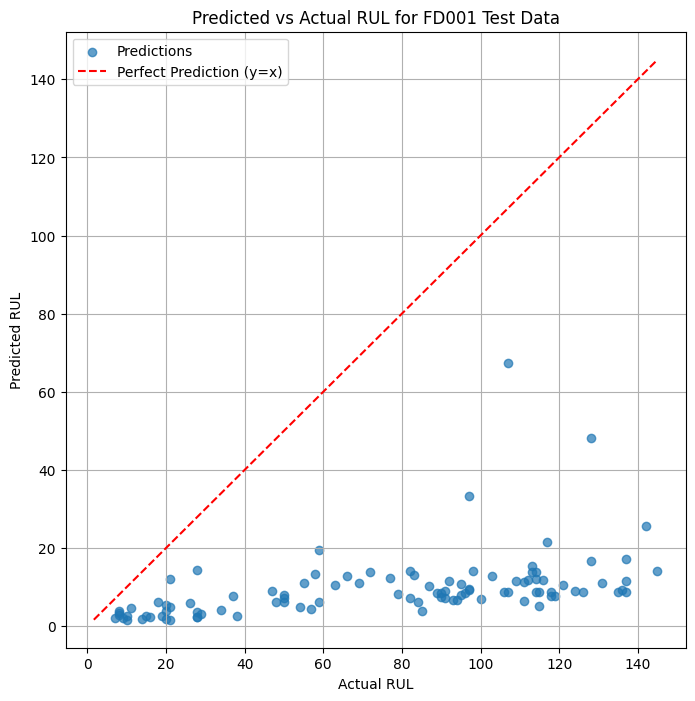

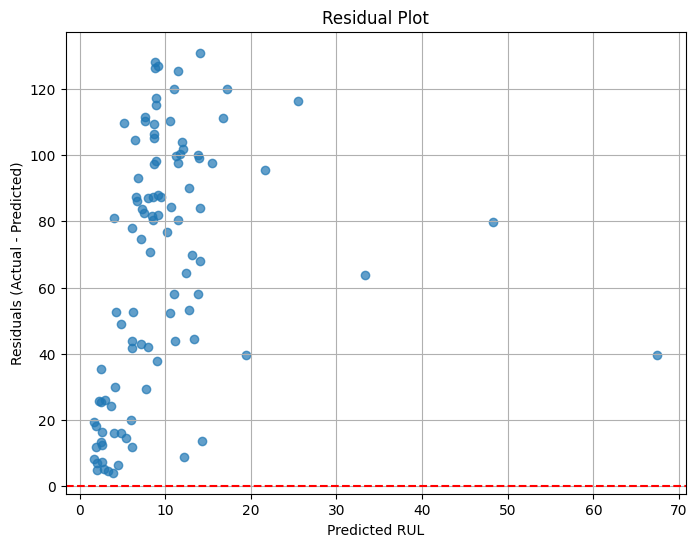

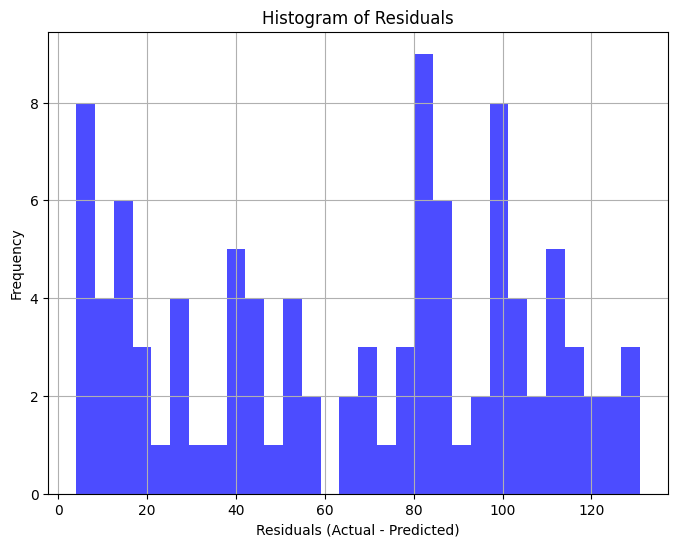

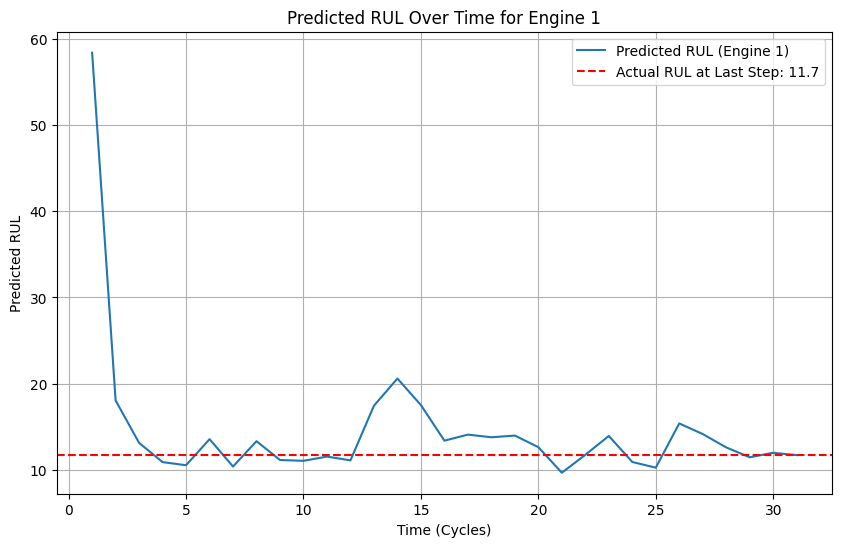

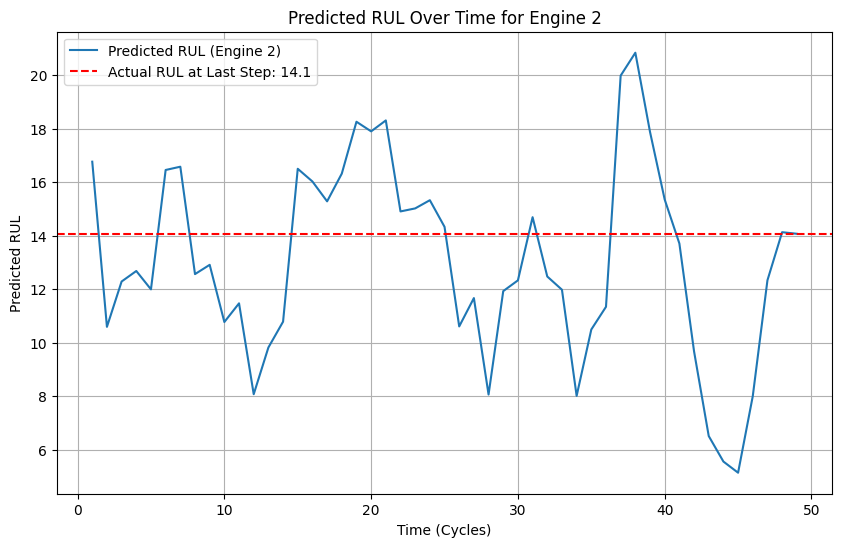

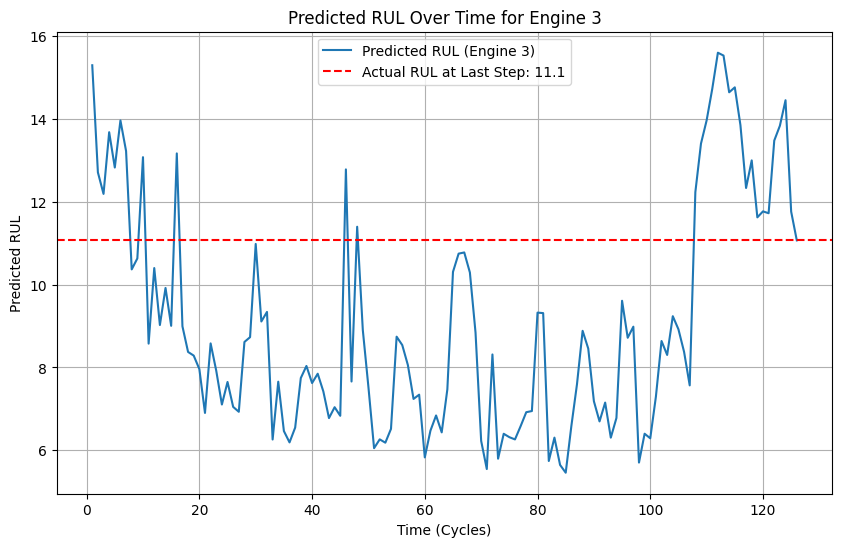

In [12]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, median_absolute_error, explained_variance_score
import matplotlib.pyplot as plt
import os

# --- Define File Paths ---
TEST_DATA_PATH = r'C:\Users\pandr\hybrid-predictive-maintenance\data\test_stage_predictions\final_stage_test_FD001.csv'
RUL_PATH = r'C:\Users\pandr\hybrid-predictive-maintenance\data\RUL_FD001.txt'
MODEL_PATH = r'C:\Users\pandr\hybrid-predictive-maintenance\models\phase4\ensemble_fd001.pkl'
FIGURES_DIR = os.path.join(os.getcwd(), 'figures', 'phase4')

# Create figures directory if it doesn’t exist
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- Regression Phase ---

# Step 1: Load test data
try:
    test_df = pd.read_csv(TEST_DATA_PATH)
    print("Test data loaded successfully.")
except FileNotFoundError:
    print(f"Error: File not found at {TEST_DATA_PATH}. Please check the path and try again.")
    raise

# Step 2: Load the ensemble model components
try:
    model_dict = joblib.load(MODEL_PATH)
    print("Loaded model dictionary with keys:", list(model_dict.keys()))
    
    # Extract individual models and scaler
    rf_model = model_dict['rf']
    xgb_model = model_dict['xgb']
    lgb_model = model_dict['lgb']
    scaler = model_dict['scaler']  # Load the scaler
except FileNotFoundError:
    print(f"Error: Model file not found at {MODEL_PATH}. Please verify the path.")
    raise
except KeyError as e:
    print(f"Error: Missing expected key {e} in the dictionary. Available keys: {list(model_dict.keys())}")
    raise

# Step 3: Get training features
training_features = rf_model.feature_names_in_
print("Training features:", training_features)

# Step 4: Feature Engineering for Test Data
# Define the list of sensors that need engineered features
sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 
           'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 
           'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

# Function to compute engineered features for each engine group
def compute_features(group):
    for sensor in sensors:
        # Rolling statistics with window=5
        group[f'{sensor}_rollmin_5'] = group[sensor].rolling(window=5, min_periods=1).min()
        group[f'{sensor}_rollmax_5'] = group[sensor].rolling(window=5, min_periods=1).max()
        group[f'{sensor}_rollstd_5'] = group[sensor].rolling(window=5, min_periods=1).std()
        # Exponential Moving Average (EMA) with span=5
        group[f'{sensor}_ema_5'] = group[sensor].ewm(span=5, adjust=False).mean()
        # Delta (difference between consecutive values)
        group[f'{sensor}_delta'] = group[sensor].diff()
    # Fill NaNs in rolling std and delta
    for sensor in sensors:
        group[f'{sensor}_rollstd_5'] = group[f'{sensor}_rollstd_5'].fillna(0)
        group[f'{sensor}_delta'] = group[f'{sensor}_delta'].fillna(method='ffill').fillna(0)
    # Compute sensor_2_3_ratio, handling division by zero
    group['sensor_2_3_ratio'] = group['sensor_2'] / group['sensor_3'].replace(0, np.nan)
    group['sensor_2_3_ratio'] = group['sensor_2_3_ratio'].fillna(0)
    return group

# Apply feature engineering to test_df, grouped by 'unit'
test_df = test_df.groupby('unit').apply(compute_features, include_groups=False).reset_index()

# Step 5: Verify and select features
# Check for missing or extra features
missing_features = [feat for feat in training_features if feat not in test_df.columns]
extra_features = [feat for feat in test_df.columns if feat not in training_features]
if missing_features:
    raise ValueError(f"Test data is missing features: {missing_features}")
if extra_features:
    print(f"Warning: Dropping extra features from test data: {extra_features}")

# Select and order test data columns to match training features
X_test = test_df[training_features]
# Apply scaling to match training data
X_test_scaled = scaler.transform(X_test)

# Step 6: Predict with each model
rf_pred = rf_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)
lgb_pred = lgb_model.predict(X_test_scaled)

# Step 7: Combine predictions (weighted average for better performance)
# Adjust weights based on validation performance (example weights)
y_pred = 0.4 * rf_pred + 0.3 * xgb_pred + 0.3 * lgb_pred
# Clip predictions to match training RUL range (if capped during training)
y_pred = np.clip(y_pred, 0, 130)  # Example: cap RUL at 130 cycles
test_df['predicted_RUL'] = y_pred

# Step 8: Extract predicted RUL for the last time step of each engine
last_rows = test_df.groupby('unit').last().reset_index()
predicted_RUL_last = last_rows['predicted_RUL'].values

# Step 9: Load ground truth RUL
try:
    rul_df = pd.read_csv(RUL_PATH, header=None)
    rul_values = rul_df[0].values
except FileNotFoundError:
    print(f"Error: RUL file not found at {RUL_PATH}. Please check the path.")
    raise

# Verify the number of engines matches
if len(last_rows) != len(rul_values):
    raise ValueError(f"Mismatch in number of engines: {len(last_rows)} in test data vs {len(rul_values)} in RUL file.")

# Step 10: Evaluate the model with additional metrics
rmse = np.sqrt(mean_squared_error(rul_values, predicted_RUL_last))
mae = mean_absolute_error(rul_values, predicted_RUL_last)
r2 = r2_score(rul_values, predicted_RUL_last)
mape = mean_absolute_percentage_error(rul_values, predicted_RUL_last)
medae = median_absolute_error(rul_values, predicted_RUL_last)
evs = explained_variance_score(rul_values, predicted_RUL_last)

# Custom scoring function (penalize underestimation more heavily)
def custom_score(y_true, y_pred):
    errors = y_true - y_pred
    penalty = np.where(errors > 0, 1.5 * errors, errors)  # 1.5x penalty for underestimation
    return np.mean(np.abs(penalty))

custom_err = custom_score(rul_values, predicted_RUL_last)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.4f}")
print(f"Median Absolute Error: {medae:.4f}")
print(f"Explained Variance Score: {evs:.4f}")
print(f"Custom Score (with underestimation penalty): {custom_err:.4f}")

# Step 11: Plot predicted vs actual RUL with a diagonal reference line
plt.figure(figsize=(8, 8))
plt.scatter(rul_values, predicted_RUL_last, alpha=0.7, label='Predictions')
# Add diagonal line (y=x)
min_val = min(min(rul_values), min(predicted_RUL_last))
max_val = max(max(rul_values), max(predicted_RUL_last))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction (y=x)')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Predicted vs Actual RUL for FD001 Test Data')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, 'predicted_vs_actual_RUL.png'))
plt.show()

# Step 12: Residual Plot
residuals = rul_values - predicted_RUL_last
plt.figure(figsize=(8, 6))
plt.scatter(predicted_RUL_last, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted RUL')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, 'residual_plot.png'))
plt.show()

# Step 13: Histogram of Residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, alpha=0.7, color='blue')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.grid(True)
plt.savefig(os.path.join(FIGURES_DIR, 'residual_histogram.png'))
plt.show()

# Step 14: Plot Predictions Over Time for a Few Engines
for unit in test_df['unit'].unique()[:3]:  # First 3 engines
    engine_data = test_df[test_df['unit'] == unit]
    plt.figure(figsize=(10, 6))
    plt.plot(engine_data['time'], engine_data['predicted_RUL'], label=f'Predicted RUL (Engine {unit})')
    # Add actual RUL at the last time step
    actual_rul = last_rows[last_rows['unit'] == unit]['predicted_RUL'].iloc[0]
    plt.axhline(y=actual_rul, color='red', linestyle='--', label=f'Actual RUL at Last Step: {actual_rul:.1f}')
    plt.xlabel('Time (Cycles)')
    plt.ylabel('Predicted RUL')
    plt.title(f'Predicted RUL Over Time for Engine {unit}')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_DIR, f'rul_over_time_engine_{unit}.png'))
    plt.show()